In [ ]:
!pip install diffusers transformers accelerate --quiet
!pip install datasets --quiet
!pip install ftfy regex tqdm --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

import os
import gc
import torch
import clip
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from torchvision.transforms.functional import to_pil_image

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


In [ ]:
from datasets import load_dataset

# Stream 1000 samples from the pixparse/cc3m-wds dataset
streamed_dataset = load_dataset("pixparse/cc3m-wds", split="train", streaming=True)

from itertools import islice
subset = list(islice(streamed_dataset, 30000))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.43k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/576 [00:00<?, ?it/s]

In [ ]:
import time

In [ ]:
start = time.time()
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-L/14", device=device)
stop = time.time()
print(f"Time taken: {stop-start}")

100%|███████████████████████████████████████| 890M/890M [00:10<00:00, 88.5MiB/s]


Time taken: 21.551363468170166


In [ ]:
# Assuming 'subset' already exists with 1000 entries
start = time.time()
os.makedirs("cc3m_streamed_images", exist_ok=True)

image_paths = []
captions = []

for i, example in enumerate(subset):
    try:
        img = example["jpg"]
        caption = example["txt"]
        path = f"cc3m_streamed_images/img_{i}.jpg"
        img.save(path)
        image_paths.append(path)
        captions.append(caption)
    except Exception as e:
        print(f"Error at {i}: {e}")

stop = time.time()
print(f"Time taken: {stop-start}")

Time taken: 48.20877289772034


In [ ]:
start = time.time()

batch_size = 32
image_embeddings = []
text_embeddings = []

progress = tqdm(range(0, len(image_paths), batch_size))

for i in progress:
    progress.write(f"📦 Processing batch starting at index {i}")

    paths_batch = image_paths[i:i+batch_size]
    captions_batch = captions[i:i+batch_size]
    images = []

    for path in paths_batch:
        try:
            img = Image.open(path).convert("RGB")
            images.append(preprocess(img))
        except:
            continue

    if len(images) == 0:
        continue

    image_input = torch.stack(images).to(device)
    text_input = clip.tokenize(captions_batch).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_input)

        # ✅ Normalize CLIP embeddings
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    image_embeddings.append(image_features.cpu())
    text_embeddings.append(text_features.cpu())

stop = time.time()
print(f"Time taken: {stop-start}")

  0%|          | 0/938 [00:00<?, ?it/s]

📦 Processing batch starting at index 0


  0%|          | 1/938 [00:01<21:10,  1.36s/it]

📦 Processing batch starting at index 32


  0%|          | 2/938 [00:01<12:41,  1.23it/s]

...

📦 Processing batch starting at index 29952


100%|█████████▉| 937/938 [07:16<00:00,  2.17it/s]

📦 Processing batch starting at index 29984


100%|██████████| 938/938 [07:16<00:00,  2.15it/s]

Time taken: 436.60770535469055


In [ ]:
image_embeddings = torch.cat(image_embeddings, dim=0)
text_embeddings = torch.cat(text_embeddings, dim=0)

torch.save(image_embeddings, "clip_image_embeddings.pt")
torch.save(text_embeddings, "clip_text_embeddings.pt")

print("✅ Embeddings saved.")

✅ Embeddings saved.


In [ ]:
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(device).eval()
preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

latents = []
for filename in tqdm(sorted(os.listdir("cc3m_streamed_images"))):
    path = os.path.join("cc3m_streamed_images", filename)
    try:
        img = Image.open(path).convert("RGB")
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            latent = vae.encode(img_tensor).latent_dist.sample() * 0.18215
        latents.append(latent.cpu())
    except Exception as e:
        print(f"Skipping {filename}: {e}")

latents_tensor = torch.cat(latents)
torch.save(latents_tensor, "vae_latents.pt")

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

100%|██████████| 30000/30000 [11:38<00:00, 42.96it/s]


In [ ]:
class LDMText2ImageDataset(Dataset):
    def __init__(self, latent_file, embedding_file):
        self.latents = torch.load(latent_file)
        self.embeddings = torch.load(embedding_file)
    def __len__(self):
        return len(self.latents)
    def __getitem__(self, idx):
        return {
            "latent": self.latents[idx],
            "embedding": self.embeddings[idx]
        }

dataset = LDMText2ImageDataset("vae_latents.pt", "clip_text_embeddings.pt")
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)


In [ ]:
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet").to(device).train()
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

In [ ]:
optimizer = AdamW(unet.parameters(), lr=1e-4)
mse_loss = nn.MSELoss()

In [ ]:
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils import clip_grad_norm_
from sklearn.model_selection import train_test_split

# ✅ Split data: 90% train, 10% validation
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [int(0.9 * len(dataset)), len(dataset) - int(0.9 * len(dataset))])
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# ✅ Optimizer and Scheduler
optimizer = AdamW(unet.parameters(), lr=5e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=5)
mse_loss = nn.MSELoss()

# ✅ Loss trackers
train_losses = []
val_losses = []
num_epochs = 5

for epoch in range(num_epochs):
    unet.train()
    total_loss = 0

    for step, batch in enumerate(tqdm(train_loader)):
        try:
            latents = batch["latent"].float().to(device)
            text_embed = batch["embedding"].float().to(device)
            noise = torch.randn_like(latents).float()

            # ✅ CFG: randomly drop conditioning (10% of the time)
            if torch.rand(1).item() < 0.1:
                text_embed = torch.zeros_like(text_embed)

            # Diffusion timestep
            bsz = latents.shape[0]
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()

            # Forward process
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            text_embed = text_embed.unsqueeze(1)  # [B, 1, 768]

            # Predict noise
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embed).sample

            # Loss and optimization
            loss = mse_loss(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()
            clip_grad_norm_(unet.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            train_losses.append(loss.item())

            if step % 10 == 0:
                print(f"[Epoch {epoch+1} | Step {step}] Train Loss: {loss.item():.4f}")

        except RuntimeError as e:
            print(f"[Step {step}] Runtime error: {e}")
            torch.cuda.empty_cache()
            gc.collect()
            continue

    scheduler.step()
    avg_train_loss = total_loss / len(train_loader)
    print(f"✅ Epoch {epoch+1} Train Loss: {avg_train_loss:.4f}")

    # ✅ Validation loop
    unet.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            latents = batch["latent"].float().to(device)
            text_embed = batch["embedding"].float().to(device)
            noise = torch.randn_like(latents).float()
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            text_embed = text_embed.unsqueeze(1)
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embed).sample
            loss = mse_loss(noise_pred, noise)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"✅ Epoch {epoch+1} Validation Loss: {avg_val_loss:.4f}")

    # 💾 Save checkpoint
    torch.save(unet.state_dict(), f"unet_epoch_{epoch+1}.pt")
    print(f"📦 Saved model at epoch {epoch+1}")

# 📊 Plot training + validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(torch.linspace(0, len(train_losses), steps=len(val_losses)), val_losses, label='Validation Loss', color='orange')
plt.title("Training & Validation Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


  0%|          | 1/3375 [00:01<1:30:27,  1.61s/it]

[Epoch 1 | Step 0] Train Loss: 0.1119


  0%|          | 11/3375 [00:09<46:07,  1.22it/s]

[Epoch 1 | Step 10] Train Loss: 0.0519


  1%|          | 21/3375 [00:17<46:09,  1.21it/s]

...

[Epoch 4 | Step 10] Train Loss: 0.1044


  1%|          | 21/3375 [00:17<46:09,  1.21it/s]

[Epoch 4 | Step 20] Train Loss: 0.1822


  1%|          | 24/3375 [00:20<46:34,  1.20it/s]


KeyboardInterrupt: 

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

NameError: name 'torch' is not defined

In [ ]:
unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet"
).to(device)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_path = "/content/drive/MyDrive/GenieVision/unet_epoch_1.pt"  # update path as needed
unet.load_state_dict(torch.load(model_path, map_location=device))
unet.eval()

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [ ]:
vae = AutoencoderKL.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="vae"
).to(device).eval()

In [ ]:
clip_model, preprocess = clip.load("ViT-L/14", device=device)

In [ ]:
# ✅ Set up DDPM scheduler
scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(50)  # use 50 for faster generation

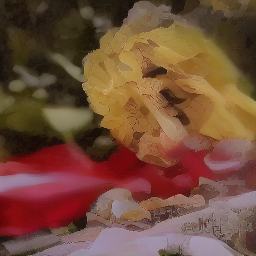

In [ ]:
# ✅ Define prompt and CFG parameters
prompt = "mickey mouse"
guidance_scale = 7.5  # Try 5–7.5 for strong CFG

# ✅ Encode text (both conditional + unconditional)
with torch.no_grad():
    cond_embed = clip_model.encode_text(clip.tokenize([prompt]).to(device)).float()
    cond_embed = cond_embed / cond_embed.norm(dim=-1, keepdim=True)
    cond_embed = cond_embed.unsqueeze(1)  # [1, 1, 768]

    uncond_embed = torch.zeros_like(cond_embed).to(device)

    # Combine for CFG
    text_embed = torch.cat([uncond_embed, cond_embed], dim=0)  # [2, 1, 768]

# ✅ Start from pure noise latent
latent = torch.randn(1, 4, 32, 32).to(device)

# ✅ Denoising with CFG
for t in scheduler.timesteps:
    latent_in = latent.repeat(2, 1, 1, 1)  # [2, 4, 32, 32]
    with torch.no_grad():
        noise_pred = unet(latent_in, t, encoder_hidden_states=text_embed).sample
        noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)

        # Apply classifier-free guidance
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)

    latent = scheduler.step(noise_pred, t, latent).prev_sample

# ✅ Decode latent to image
with torch.no_grad():
    decoded = vae.decode(latent / 0.18215).sample  # [1, 3, 256, 256]

# ✅ Convert to image and display
img = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
display(img)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

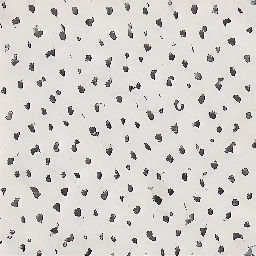

In [ ]:
# ✅ Install (if not already done)
# !pip install diffusers transformers accelerate --quiet

# ✅ Imports
import torch
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel
from torchvision.transforms.functional import to_pil_image
from PIL import Image
from IPython.display import display

# ✅ Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# ✅ Load UNet and your trained weights
unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet"
).to(device)

model_path = "/content/drive/MyDrive/GenieVision/unet_epoch_3.pt"  # update path
unet.load_state_dict(torch.load(model_path, map_location=device))
unet.eval()

# ✅ Load pretrained VAE decoder
vae = AutoencoderKL.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="vae"
).to(device).eval()

# ✅ Load HuggingFace CLIP tokenizer + text encoder
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device)

# ✅ Your text prompt
prompt = "mushroom lying on a white background"
guidance_scale = 5.0  # Adjust between 5–7.5 for stronger prompt control

# ✅ Encode prompt and unconditional (empty) text
with torch.no_grad():
    # Tokenize and encode the real prompt
    tokens = tokenizer([prompt], padding="max_length", truncation=True, return_tensors="pt").to(device)
    cond_embed = text_encoder(**tokens).last_hidden_state  # [1, 77, 768]

    # Tokenize and encode the empty prompt (for CFG)
    uncond_tokens = tokenizer([""], padding="max_length", return_tensors="pt").to(device)
    uncond_embed = text_encoder(**uncond_tokens).last_hidden_state  # [1, 77, 768]

    # Combine for classifier-free guidance
    text_embed = torch.cat([uncond_embed, cond_embed], dim=0)  # [2, 77, 768]

# ✅ Noise scheduler setup
scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(50)

# ✅ Start from pure noise
latent = torch.randn(1, 4, 32, 32).to(device)

# ✅ Denoising with CFG
for t in scheduler.timesteps:
    latent_in = latent.repeat(2, 1, 1, 1)  # [2, 4, 32, 32]
    with torch.no_grad():
        noise_pred = unet(latent_in, t, encoder_hidden_states=text_embed).sample
        noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)

    latent = scheduler.step(noise_pred, t, latent).prev_sample

# ✅ Decode latent to image
with torch.no_grad():
    decoded = vae.decode(latent / 0.18215).sample  # [1, 3, 256, 256]

# ✅ Convert and display image
img = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
display(img)
# Optional: img.save("generated_mushroom.png")


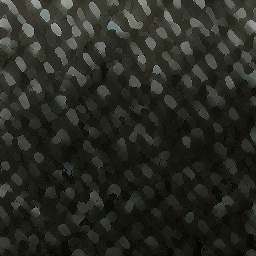

In [ ]:
# ✅ Your text prompt
prompt = "actor with white background"
guidance_scale = 5  # Adjust between 5–7.5 for stronger prompt control

# ✅ Encode prompt and unconditional (empty) text
with torch.no_grad():
    # Tokenize and encode the real prompt
    tokens = tokenizer([prompt], padding="max_length", truncation=True, return_tensors="pt").to(device)
    cond_embed = text_encoder(**tokens).last_hidden_state  # [1, 77, 768]

    # Tokenize and encode the empty prompt (for CFG)
    uncond_tokens = tokenizer([""], padding="max_length", return_tensors="pt").to(device)
    uncond_embed = text_encoder(**uncond_tokens).last_hidden_state  # [1, 77, 768]

    # Combine for classifier-free guidance
    text_embed = torch.cat([uncond_embed, cond_embed], dim=0)  # [2, 77, 768]

# ✅ Noise scheduler setup
scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(50)

# ✅ Start from pure noise
latent = torch.randn(1, 4, 32, 32).to(device)

# ✅ Denoising with CFG
for t in scheduler.timesteps:
    latent_in = latent.repeat(2, 1, 1, 1)  # [2, 4, 32, 32]
    with torch.no_grad():
        noise_pred = unet(latent_in, t, encoder_hidden_states=text_embed).sample
        noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)

    latent = scheduler.step(noise_pred, t, latent).prev_sample

# ✅ Decode latent to image
with torch.no_grad():
    decoded = vae.decode(latent / 0.18215).sample  # [1, 3, 256, 256]

# ✅ Convert and display image
img = to_pil_image(decoded.squeeze().clamp(-1, 1) * 0.5 + 0.5)
display(img)
# Optional: img.save("generated_mushroom.png")